# PTEN/UCEC Reproducible Survival Analysis

**Phase 1: independent survival rerun**  
**Phase 2: PTEN alteration frequency across TCGA molecular subtypes**

This notebook rebuilds the PTEN altered-versus-unaltered survival analysis from the supplied Firehose Legacy exports and then performs a new molecular-subtype association analysis using the supplied TCGA PanCancer Atlas clinical files.

Every cleaning step, exclusion, statistical result, and figure is generated in code and saved automatically.

**Important distinctions**

- The survival rerun is a reproducible sensitivity analysis, not an exact replication of cBioPortal's internal 543-patient portal analysis.
- The subtype analysis combines PTEN status from the supplied Firehose Legacy sample matrix with molecular-subtype labels from the PanCancer Atlas clinical files by exact TCGA sample and patient identifiers.
- Both analyses are descriptive and hypothesis-generating.


## 1. Research questions and analysis definitions

### Phase 1: survival rerun

**Question:** In the available exported TCGA-UCEC patient-level data, is overall survival different between PTEN-altered and PTEN-unaltered tumors?

**Exploratory hypothesis:** Overall-survival distributions differ between the two groups.

**Methods:** Kaplan–Meier curves, a two-sided log-rank test, and an unadjusted Cox proportional-hazards model.

### Phase 2: molecular-subtype extension

**Question:** Is PTEN alteration frequency associated with TCGA molecular subtype in uterine corpus endometrial carcinoma?

**Hypothesis:** PTEN alteration frequency differs across the four TCGA-UCEC molecular subtypes.

**Primary Phase 2 cohort:** PanCancer Atlas primary tumor samples that have:
1. an exact sample-level match to the supplied PTEN altered/unaltered matrix; and
2. a nonmissing molecular-subtype label.

**Methods:** A 4 × 2 Pearson chi-square test, Cramér's V, adjusted standardized residuals, Wilson 95% confidence intervals, and pairwise Fisher exact tests with Holm correction.

**Scope:** Unadjusted association analyses. They do not establish causation, independent prognosis, or treatment response.


In [1]:
from pathlib import Path
import hashlib
import importlib.metadata as metadata
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import logrank_test, proportional_hazard_test

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data_raw"
PROCESSED_DIR = PROJECT_ROOT / "data_processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

for directory in [PROCESSED_DIR, RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05
print(f"Project root: {PROJECT_ROOT}")

Project root: /mnt/data/pten_work/PTEN_UCEC_OCSEF_Reproducible_Extension


## 2. Record software versions and raw-file checksums

Checksums document the exact raw files analyzed. If a raw file changes, its SHA-256 checksum will also change.

In [2]:
packages = ["pandas", "numpy", "matplotlib", "scipy", "lifelines", "notebook", "nbformat", "ipykernel"]
version_rows = [{"software": "Python", "version": platform.python_version()}]
for package in packages:
    try:
        version_rows.append({"software": package, "version": metadata.version(package)})
    except metadata.PackageNotFoundError:
        version_rows.append({"software": package, "version": "not installed"})

software_versions = pd.DataFrame(version_rows)
software_versions.to_csv(RESULTS_DIR / "software_versions.csv", index=False)
display(software_versions)

raw_files = sorted(RAW_DIR.glob("*"))
checksum_rows = []
for path in raw_files:
    if path.is_file():
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        checksum_rows.append({
            "file_name": path.name,
            "size_bytes": path.stat().st_size,
            "sha256": digest,
        })
raw_checksums = pd.DataFrame(checksum_rows)
raw_checksums.to_csv(RESULTS_DIR / "raw_file_checksums.csv", index=False)
display(raw_checksums)

,software,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.3.5
3,matplotlib,3.10.8
4,scipy,1.17.0
5,lifelines,0.30.0
6,notebook,7.5.3
7,nbformat,5.10.4
8,ipykernel,7.2.0


,file_name,size_bytes,sha256
0,README_original_supplementary_files.txt,3369,87e92518c1cbc75515ad670baf19fc091d6f54e848d0f4...
1,Supplementary_Table_S1_PTEN_altered_unaltered_...,16500,4fd1d1cadf55027f8c060214ae532ab08d44dfd553597b...
2,Supplementary_Table_S2_PTEN_discrete_CNA_table...,15485,8c22b0b2d3ccfde63d91021001968bab506c2836494a3d...
3,Supplementary_Table_S3_PTEN_mutation_table.tsv,303326,736c0934cc10d77285f320412ce2b431f9139385e8f7ad...
4,Supplementary_Table_S4_cBioPortal_clinical_sur...,324300,3d7d0ad0101170461321d65953e817485c512ecf77adb7...
5,Supplementary_Table_S5_cBioPortal_PTEN_surviva...,290,1c5ef366d549d30e77c5563144f3628dc60fef124bdd99...
6,data_clinical_patient.txt,162724,7a3f868cdd4fbce611087c86b6f9a657e600e2a630c576...
7,data_clinical_sample.txt,112480,205a1081c4d51441b4ee6d4302d9c42dac1320b9f51c87...


## 3. Load the supplied raw files

The analysis uses the original files in `data_raw/` without editing them.

In [3]:
S1_FILE = RAW_DIR / "Supplementary_Table_S1_PTEN_altered_unaltered_sample_matrix.tsv"
S4_FILE = RAW_DIR / "Supplementary_Table_S4_cBioPortal_clinical_survival_table.tsv"
S5_FILE = RAW_DIR / "Supplementary_Table_S5_cBioPortal_PTEN_survival_summary_table.tsv"

for required_file in [S1_FILE, S4_FILE, S5_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(f"Missing required raw file: {required_file}")

s1 = pd.read_csv(S1_FILE, sep="	")
s4 = pd.read_csv(S4_FILE, sep="	")
s5 = pd.read_csv(S5_FILE, sep="	")

print("S1 PTEN status matrix rows:", len(s1))
print("S4 clinical/survival rows:", len(s4))
print("S5 portal survival summary rows:", len(s5))

S1 PTEN status matrix rows: 549
S4 clinical/survival rows: 500
S5 portal survival summary rows: 2


## 4. Validate schemas, identifiers, and PTEN-status coding

In [4]:
required_s1 = {"studyID:sampleId", "Altered", "PTEN"}
required_s4 = {"patientId", "sampleId", "OS_MONTHS", "OS_STATUS"}
required_s5 = {"Survival Type", "Number of Patients", "# in Altered group", "# in Unaltered group", "p-Value"}

missing_s1 = required_s1 - set(s1.columns)
missing_s4 = required_s4 - set(s4.columns)
missing_s5 = required_s5 - set(s5.columns)
if missing_s1 or missing_s4 or missing_s5:
    raise ValueError({"missing_s1": sorted(missing_s1), "missing_s4": sorted(missing_s4), "missing_s5": sorted(missing_s5)})

s1 = s1.copy()
s1["sampleId"] = s1["studyID:sampleId"].astype(str).str.split(":", n=1).str[-1]
s1["patientId_derived"] = s1["sampleId"].str.split("-").str[:3].str.join("-")
s1["Altered"] = pd.to_numeric(s1["Altered"], errors="coerce")

if s1["sampleId"].duplicated().any():
    raise ValueError("Duplicate sample IDs were found in S1.")
if s4["sampleId"].duplicated().any():
    raise ValueError("Duplicate sample IDs were found in S4.")
if s4["patientId"].duplicated().any():
    raise ValueError("Duplicate patient IDs were found in S4.")
if not set(s1["Altered"].dropna().unique()).issubset({0, 1}):
    raise ValueError("Unexpected PTEN Altered coding; expected only 0 and 1.")

id_consistency = (s4["sampleId"].str.split("-").str[:3].str.join("-") == s4["patientId"]).all()
print("S4 sample-to-patient ID consistency:", id_consistency)
print("S1 unique sample IDs:", s1["sampleId"].nunique())
print("S4 unique sample IDs:", s4["sampleId"].nunique())
print("S1 altered counts:")
display(s1["Altered"].value_counts(dropna=False).rename_axis("Altered").reset_index(name="n"))

S4 sample-to-patient ID consistency: True
S1 unique sample IDs: 549
S4 unique sample IDs: 500
S1 altered counts:


,Altered,n
0,0,368
1,1,181


## 5. Merge data and document every exclusion

Exclusions are derived in code. No row is manually deleted in Excel.

In [5]:
labels = s1[["sampleId", "patientId_derived", "Altered", "PTEN"]].copy()
labels["PTEN_GROUP"] = labels["Altered"].map({1: "PTEN-altered", 0: "PTEN-unaltered"})

clinical_ids = set(s4["sampleId"])
missing_clinical = labels.loc[~labels["sampleId"].isin(clinical_ids)].copy()
missing_clinical["patientId"] = missing_clinical["patientId_derived"]
missing_clinical["exclusion_reason"] = "No matching record in supplied clinical/survival export"
missing_clinical["OS_MONTHS"] = np.nan
missing_clinical["OS_STATUS"] = np.nan

merged = s4.merge(labels.drop(columns="patientId_derived"), on="sampleId", how="inner", validate="one_to_one")
merged["OS_MONTHS_NUMERIC"] = pd.to_numeric(merged["OS_MONTHS"], errors="coerce")

status_text = merged["OS_STATUS"].astype("string")
merged["OS_EVENT"] = np.select(
    [status_text.str.startswith("1:", na=False), status_text.str.startswith("0:", na=False)],
    [1.0, 0.0],
    default=np.nan,
)

merged["exclusion_reason"] = pd.NA
merged.loc[merged["OS_MONTHS_NUMERIC"].isna(), "exclusion_reason"] = "Missing or nonnumeric OS_MONTHS"
merged.loc[merged["OS_EVENT"].isna(), "exclusion_reason"] = "Unrecognized or missing OS_STATUS"
merged.loc[merged["OS_MONTHS_NUMERIC"] < 0, "exclusion_reason"] = "Negative OS_MONTHS"

survival_excluded = merged.loc[merged["exclusion_reason"].notna()].copy()
analysis = merged.loc[merged["exclusion_reason"].isna()].copy()
analysis["OS_EVENT"] = analysis["OS_EVENT"].astype(int)
analysis["Altered"] = analysis["Altered"].astype(int)

excluded_columns = ["patientId", "sampleId", "Altered", "PTEN_GROUP", "OS_MONTHS", "OS_STATUS", "exclusion_reason"]
excluded_samples = pd.concat([
    missing_clinical.reindex(columns=excluded_columns),
    survival_excluded.reindex(columns=excluded_columns),
], ignore_index=True)

analysis_columns = [
    "patientId", "sampleId", "Altered", "PTEN_GROUP", "OS_MONTHS", "OS_MONTHS_NUMERIC",
    "OS_STATUS", "OS_EVENT", "AGE", "CLINICAL_STAGE", "GRADE",
    "HISTOLOGICAL_DIAGNOSIS", "RACE"
]
analysis = analysis.reindex(columns=analysis_columns).sort_values(["PTEN_GROUP", "patientId"]).reset_index(drop=True)
excluded_samples = excluded_samples.sort_values(["exclusion_reason", "patientId"], na_position="last").reset_index(drop=True)

analysis.to_csv(PROCESSED_DIR / "survival_analysis_dataset.csv", index=False)
excluded_samples.to_csv(PROCESSED_DIR / "excluded_samples.csv", index=False)

print("Matched records before survival exclusions:", len(merged))
print("No matching clinical record:", len(missing_clinical))
print("Additional unusable survival records:", len(survival_excluded))
print("Final analyzable cohort:", len(analysis))
display(survival_excluded[excluded_columns])

Matched records before survival exclusions: 500
No matching clinical record: 49
Additional unusable survival records: 2
Final analyzable cohort: 498


,patientId,sampleId,Altered,PTEN_GROUP,OS_MONTHS,OS_STATUS,exclusion_reason
261,TCGA-AX-A3FV,TCGA-AX-A3FV-01,0,PTEN-unaltered,-0.2,0:LIVING,Negative OS_MONTHS
448,TCGA-AJ-A3BH,TCGA-AJ-A3BH-01,0,PTEN-unaltered,NaN,0:LIVING,Missing or nonnumeric OS_MONTHS


## 6. Generate the sample-flow audit and count table

,stage,total_n,altered_n,unaltered_n,deaths_n
0,PTEN sample matrix,549,181,368,NaN
1,Matched to supplied clinical export,500,146,354,85.0
2,Final analyzable survival cohort,498,146,352,85.0


,check,expected,observed,matches_expected
0,S1 total,549,549,True
1,S4 total,500,500,True
2,Analyzable total,498,498,True
3,Analyzable altered,146,146,True
4,Analyzable unaltered,352,352,True
5,Deaths,85,85,True


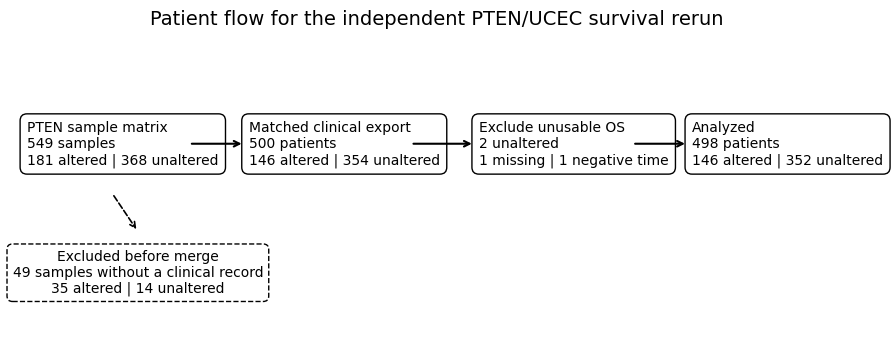

In [6]:
sample_counts = pd.DataFrame([
    {"stage": "PTEN sample matrix", "total_n": len(s1), "altered_n": int((s1["Altered"] == 1).sum()), "unaltered_n": int((s1["Altered"] == 0).sum())},
    {"stage": "Matched to supplied clinical export", "total_n": len(merged), "altered_n": int((merged["Altered"] == 1).sum()), "unaltered_n": int((merged["Altered"] == 0).sum())},
    {"stage": "Final analyzable survival cohort", "total_n": len(analysis), "altered_n": int((analysis["Altered"] == 1).sum()), "unaltered_n": int((analysis["Altered"] == 0).sum())},
])
sample_counts["deaths_n"] = [np.nan, int(merged["OS_EVENT"].fillna(0).sum()), int(analysis["OS_EVENT"].sum())]
sample_counts.to_csv(RESULTS_DIR / "sample_counts.csv", index=False)
display(sample_counts)

expected_checks = pd.DataFrame([
    {"check": "S1 total", "expected": 549, "observed": len(s1)},
    {"check": "S4 total", "expected": 500, "observed": len(s4)},
    {"check": "Analyzable total", "expected": 498, "observed": len(analysis)},
    {"check": "Analyzable altered", "expected": 146, "observed": int((analysis["Altered"] == 1).sum())},
    {"check": "Analyzable unaltered", "expected": 352, "observed": int((analysis["Altered"] == 0).sum())},
    {"check": "Deaths", "expected": 85, "observed": int(analysis["OS_EVENT"].sum())},
])
expected_checks["matches_expected"] = expected_checks["expected"] == expected_checks["observed"]
expected_checks.to_csv(RESULTS_DIR / "validation_checks.csv", index=False)
display(expected_checks)

# Write the complete audit above, then fail fast before any downstream analysis.
if not expected_checks["matches_expected"].all():
    raise RuntimeError("One or more Phase 1 expected-count validations failed.")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis("off")
main_y = 0.64
boxes = [
    (0.02, main_y, "PTEN sample matrix\n549 samples\n181 altered | 368 unaltered"),
    (0.28, main_y, "Matched clinical export\n500 patients\n146 altered | 354 unaltered"),
    (0.55, main_y, "Exclude unusable OS\n2 unaltered\n1 missing | 1 negative time"),
    (0.80, main_y, "Analyzed\n498 patients\n146 altered | 352 unaltered"),
]
for x, y, text in boxes:
    ax.text(x, y, text, transform=ax.transAxes, ha="left", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"))
for x1, x2 in [(0.21, 0.275), (0.47, 0.545), (0.73, 0.795)]:
    ax.annotate("", xy=(x2, main_y), xytext=(x1, main_y), xycoords=ax.transAxes,
                arrowprops=dict(arrowstyle="->", linewidth=1.5))
ax.text(0.15, 0.20, "Excluded before merge\n49 samples without a clinical record\n35 altered | 14 unaltered",
        transform=ax.transAxes, ha="center", va="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linestyle="--"))
ax.annotate("", xy=(0.15, 0.34), xytext=(0.12, 0.47), xycoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", linewidth=1.2, linestyle="--"))
ax.set_title("Patient flow for the independent PTEN/UCEC survival rerun", fontsize=14, pad=10)
fig.savefig(FIGURES_DIR / "patient_flow_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Kaplan-Meier curves and log-rank test

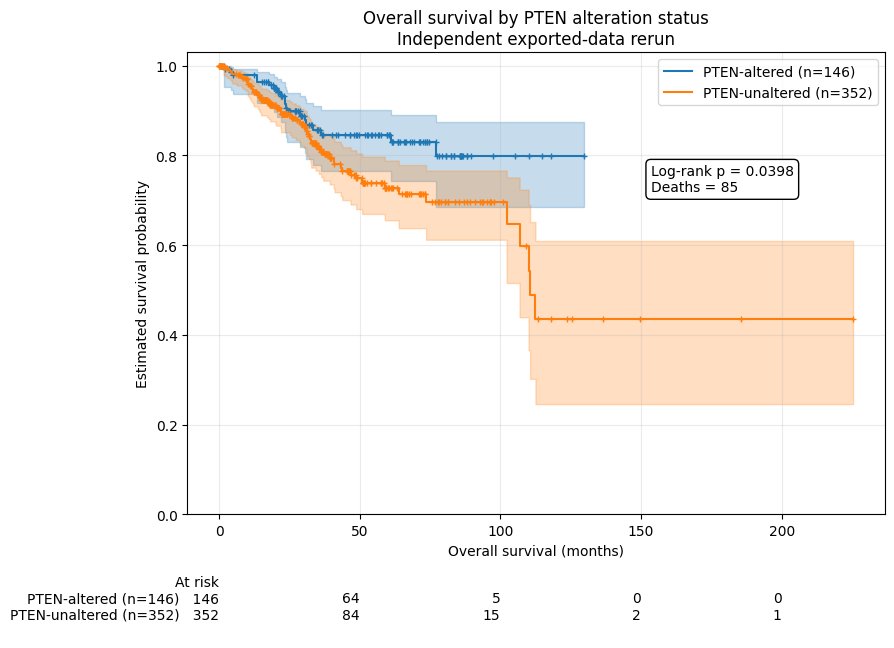

Log-rank chi-square: 4.227593
Log-rank p-value: 0.03977181


In [7]:
altered = analysis.loc[analysis["Altered"] == 1].copy()
unaltered = analysis.loc[analysis["Altered"] == 0].copy()

logrank = logrank_test(
    altered["OS_MONTHS_NUMERIC"],
    unaltered["OS_MONTHS_NUMERIC"],
    event_observed_A=altered["OS_EVENT"],
    event_observed_B=unaltered["OS_EVENT"],
    alpha=ALPHA,
)

km_altered = KaplanMeierFitter(label=f"PTEN-altered (n={len(altered)})")
km_unaltered = KaplanMeierFitter(label=f"PTEN-unaltered (n={len(unaltered)})")
km_altered.fit(altered["OS_MONTHS_NUMERIC"], event_observed=altered["OS_EVENT"])
km_unaltered.fit(unaltered["OS_MONTHS_NUMERIC"], event_observed=unaltered["OS_EVENT"])

fig, ax = plt.subplots(figsize=(9, 7))
km_altered.plot_survival_function(ax=ax, ci_show=True, show_censors=True, censor_styles={"ms": 4, "marker": "+"})
km_unaltered.plot_survival_function(ax=ax, ci_show=True, show_censors=True, censor_styles={"ms": 4, "marker": "+"})
ax.set_title("Overall survival by PTEN alteration status\nIndependent exported-data rerun")
ax.set_xlabel("Overall survival (months)")
ax.set_ylabel("Estimated survival probability")
ax.set_ylim(0, 1.03)
ax.grid(True, alpha=0.25)
add_at_risk_counts(km_altered, km_unaltered, ax=ax, rows_to_show=["At risk"])
fig.subplots_adjust(bottom=0.22)
fig.text(
    0.64, 0.72,
    f"Log-rank p = {logrank.p_value:.4f}\nDeaths = {int(analysis['OS_EVENT'].sum())}",
    ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black"),
)
fig.savefig(FIGURES_DIR / "kaplan_meier_PTEN.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Log-rank chi-square: {logrank.test_statistic:.6f}")
print(f"Log-rank p-value: {logrank.p_value:.8f}")

## 8. Unadjusted Cox proportional-hazards model and diagnostic

In [8]:
cox_df = analysis[["OS_MONTHS_NUMERIC", "OS_EVENT", "Altered"]].copy()
cph = CoxPHFitter()
cph.fit(cox_df, duration_col="OS_MONTHS_NUMERIC", event_col="OS_EVENT", formula="Altered")

cox_summary = cph.summary.reset_index().rename(columns={"covariate": "variable"})
cox_summary.to_csv(RESULTS_DIR / "cox_model_coefficients.csv", index=False)
display(cox_summary)

ph_test = proportional_hazard_test(cph, cox_df, time_transform="rank")
ph_summary = ph_test.summary.reset_index().rename(columns={"index": "variable"})
ph_summary.to_csv(RESULTS_DIR / "proportional_hazards_test.csv", index=False)
display(ph_summary)

hr = float(cox_summary.loc[0, "exp(coef)"])
ci_low = float(cox_summary.loc[0, "exp(coef) lower 95%"])
ci_high = float(cox_summary.loc[0, "exp(coef) upper 95%"])
cox_p = float(cox_summary.loc[0, "p"])
ph_p = float(ph_summary.loc[0, "p"])

print(f"Hazard ratio (altered vs unaltered): {hr:.4f}")
print(f"95% CI: {ci_low:.4f} to {ci_high:.4f}")
print(f"Cox p-value: {cox_p:.6f}")
print(f"PH diagnostic p-value (rank transform): {ph_p:.6f}")

,variable,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
0,Altered,-0.521952,0.593361,0.256675,-1.025026,-0.018878,0.358787,0.981299,0.0,-2.033511,0.042001,4.573435


,variable,test_statistic,p,-log2(p)
0,Altered,0.680053,0.409568,1.287824


Hazard ratio (altered vs unaltered): 0.5934
95% CI: 0.3588 to 0.9813
Cox p-value: 0.042001
PH diagnostic p-value (rank transform): 0.409568


## 9. Save one consolidated survival-statistics table

In [9]:
def median_text(kmf):
    value = float(kmf.median_survival_time_)
    return "Not reached" if np.isinf(value) else f"{value:.2f}"

survival_statistics = pd.DataFrame([{
    "analysis_label": "Independent exported-data rerun",
    "total_n": len(analysis),
    "altered_n": len(altered),
    "unaltered_n": len(unaltered),
    "total_deaths": int(analysis["OS_EVENT"].sum()),
    "altered_deaths": int(altered["OS_EVENT"].sum()),
    "unaltered_deaths": int(unaltered["OS_EVENT"].sum()),
    "median_os_altered_months": median_text(km_altered),
    "median_os_unaltered_months": median_text(km_unaltered),
    "logrank_chi_square": float(logrank.test_statistic),
    "logrank_p_value": float(logrank.p_value),
    "cox_hr_altered_vs_unaltered": hr,
    "cox_hr_ci95_lower": ci_low,
    "cox_hr_ci95_upper": ci_high,
    "cox_p_value": cox_p,
    "ph_test_rank_p_value": ph_p,
}])
survival_statistics.to_csv(RESULTS_DIR / "survival_statistics.csv", index=False)
display(survival_statistics.T)

,0
analysis_label,Independent exported-data rerun
total_n,498
altered_n,146
unaltered_n,352
total_deaths,85
altered_deaths,20
unaltered_deaths,65
median_os_altered_months,Not reached
median_os_unaltered_months,110.55
logrank_chi_square,4.227593


## 10. Compare the portal result with the independent rerun

The portal row is read directly from Supplementary Table S5. The independent row is generated above.

,analysis,data_basis,total_n,altered_n,unaltered_n,logrank_p_value,hazard_ratio,interpretation
0,cBioPortal portal output,Portal-generated comparison,543,181,362,0.011000,NaN,Published portal result
1,Independent exported-data rerun,S1 PTEN matrix merged with S4 clinical export,498,146,352,0.039772,0.593361,Sensitivity/reproducibility check; not exact r...


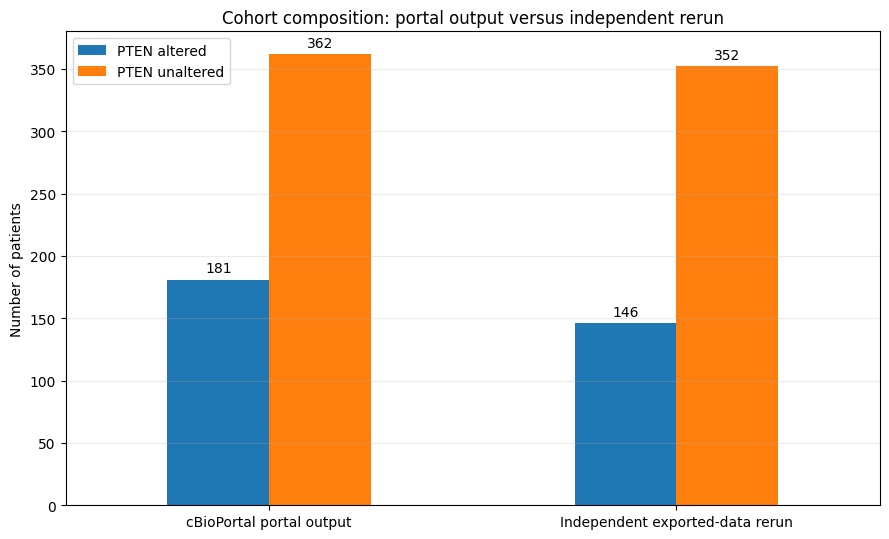

In [10]:
portal_survival_type = (
    s5["Survival Type"].astype("string").str.strip().str.casefold()
)
portal_os_rows = s5.loc[portal_survival_type.eq("overall")]
if len(portal_os_rows) != 1:
    raise ValueError(
        "Expected exactly one overall-survival row in S5; "
        f"found {len(portal_os_rows)}."
    )
portal_os = portal_os_rows.iloc[0]
comparison = pd.DataFrame([
    {
        "analysis": "cBioPortal portal output",
        "data_basis": "Portal-generated comparison",
        "total_n": int(portal_os["Number of Patients"]),
        "altered_n": int(portal_os["# in Altered group"]),
        "unaltered_n": int(portal_os["# in Unaltered group"]),
        "logrank_p_value": float(portal_os["p-Value"]),
        "hazard_ratio": np.nan,
        "interpretation": "Published portal result",
    },
    {
        "analysis": "Independent exported-data rerun",
        "data_basis": "S1 PTEN matrix merged with S4 clinical export",
        "total_n": len(analysis),
        "altered_n": len(altered),
        "unaltered_n": len(unaltered),
        "logrank_p_value": float(logrank.p_value),
        "hazard_ratio": hr,
        "interpretation": "Sensitivity/reproducibility check; not exact replication",
    },
])
comparison.to_csv(RESULTS_DIR / "portal_vs_rerun_comparison.csv", index=False)
display(comparison)

plot_df = comparison.set_index("analysis")[["altered_n", "unaltered_n"]]
ax = plot_df.plot(kind="bar", figsize=(9, 5.5))
ax.set_title("Cohort composition: portal output versus independent rerun")
ax.set_xlabel("")
ax.set_ylabel("Number of patients")
ax.tick_params(axis="x", rotation=0)
ax.legend(["PTEN altered", "PTEN unaltered"])
ax.grid(axis="y", alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, padding=3)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "portal_vs_rerun_counts.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Final output audit

This cell checks that the required files were created and prints the cautious interpretation.

In [11]:
required_outputs = [
    PROCESSED_DIR / "survival_analysis_dataset.csv",
    PROCESSED_DIR / "excluded_samples.csv",
    RESULTS_DIR / "sample_counts.csv",
    RESULTS_DIR / "survival_statistics.csv",
    RESULTS_DIR / "cox_model_coefficients.csv",
    RESULTS_DIR / "proportional_hazards_test.csv",
    RESULTS_DIR / "portal_vs_rerun_comparison.csv",
    RESULTS_DIR / "software_versions.csv",
    RESULTS_DIR / "raw_file_checksums.csv",
    RESULTS_DIR / "validation_checks.csv",
    FIGURES_DIR / "kaplan_meier_PTEN.png",
    FIGURES_DIR / "patient_flow_diagram.png",
    FIGURES_DIR / "portal_vs_rerun_counts.png",
]
output_audit = pd.DataFrame({
    "output": [str(path.relative_to(PROJECT_ROOT)) for path in required_outputs],
    "exists": [path.exists() for path in required_outputs],
    "size_bytes": [path.stat().st_size if path.exists() else 0 for path in required_outputs],
})
output_audit.to_csv(RESULTS_DIR / "phase1_output_audit.csv", index=False)
display(output_audit)

if not output_audit["exists"].all():
    raise RuntimeError("One or more required outputs were not generated.")

print("cautious interpretation:")
print(
    "An independent patient-level rerun using the available exported files produced "
    "a smaller analyzable cohort than the cBioPortal portal analysis. Although the exact "
    "cohort and p-value differed, the rerun supported the same general unadjusted survival "
    "association. This is a sensitivity and reproducibility check, not an exact replication."
)
print("\nPhase 1 completed successfully. Continuing to the molecular-subtype extension.")

,output,exists,size_bytes
0,data_processed/survival_analysis_dataset.csv,True,67440
1,data_processed/excluded_samples.csv,True,5268
2,results/sample_counts.csv,True,180
3,results/survival_statistics.csv,True,479
4,results/cox_model_coefficients.csv,True,331
5,results/proportional_hazards_test.csv,True,99
6,results/portal_vs_rerun_comparison.csv,True,375
7,results/software_versions.csv,True,151
8,results/raw_file_checksums.csv,True,978
9,results/validation_checks.csv,True,199


cautious interpretation:
An independent patient-level rerun using the available exported files produced a smaller analyzable cohort than the cBioPortal portal analysis. Although the exact cohort and p-value differed, the rerun supported the same general unadjusted survival association. This is a sensitivity and reproducibility check, not an exact replication.

Phase 1 completed successfully. Continuing to the molecular-subtype extension.


## 12. Load and validate the PanCancer Atlas molecular-subtype files

The patient file contains the molecular-subtype label. The sample file identifies the exact primary tumor sample selected for each patient. Using both files prevents a patient with multiple Firehose samples from being counted twice or assigned the wrong sample-level PTEN status.

The raw subtype labels are preserved. A separate readable label is created only for tables and figures.


In [12]:

PATIENT_FILE = RAW_DIR / "data_clinical_patient.txt"
SAMPLE_FILE = RAW_DIR / "data_clinical_sample.txt"

for required_file in [PATIENT_FILE, SAMPLE_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(f"Missing required subtype file: {required_file}")

def read_cbioportal_clinical(path):
    return pd.read_csv(
        path,
        sep="\t",
        comment="#",
        dtype=str,
        na_values=["NA", "NaN", ""],
        keep_default_na=True,
    )

pan_patient = read_cbioportal_clinical(PATIENT_FILE)
pan_sample = read_cbioportal_clinical(SAMPLE_FILE)

required_patient = {"PATIENT_ID", "SUBTYPE", "CANCER_TYPE_ACRONYM", "IN_PANCANPATHWAYS_FREEZE"}
required_sample = {"PATIENT_ID", "SAMPLE_ID", "SAMPLE_TYPE"}
missing_patient_columns = required_patient - set(pan_patient.columns)
missing_sample_columns = required_sample - set(pan_sample.columns)
if missing_patient_columns or missing_sample_columns:
    raise ValueError({
        "missing_patient_columns": sorted(missing_patient_columns),
        "missing_sample_columns": sorted(missing_sample_columns),
    })

for frame, columns in [
    (pan_patient, ["PATIENT_ID", "SUBTYPE"]),
    (pan_sample, ["PATIENT_ID", "SAMPLE_ID"]),
]:
    for column in columns:
        frame[column] = frame[column].astype("string").str.strip().str.upper()

if pan_patient["PATIENT_ID"].duplicated().any():
    raise ValueError("Duplicate patient identifiers were found in data_clinical_patient.txt.")
if pan_sample["PATIENT_ID"].duplicated().any():
    raise ValueError("Duplicate patient identifiers were found in data_clinical_sample.txt.")
if pan_sample["SAMPLE_ID"].duplicated().any():
    raise ValueError("Duplicate sample identifiers were found in data_clinical_sample.txt.")

allowed_subtypes = {"UCEC_POLE", "UCEC_MSI", "UCEC_CN_LOW", "UCEC_CN_HIGH"}
observed_subtypes = set(pan_patient["SUBTYPE"].dropna().unique())
unexpected_subtypes = observed_subtypes - allowed_subtypes
if unexpected_subtypes:
    raise ValueError(f"Unexpected subtype labels: {sorted(unexpected_subtypes)}")

patient_sample_sets_equal = set(pan_patient["PATIENT_ID"]) == set(pan_sample["PATIENT_ID"])
sample_prefix_consistent = (pan_sample["SAMPLE_ID"].str[:12] == pan_sample["PATIENT_ID"]).all()
all_primary = pan_sample["SAMPLE_TYPE"].eq("Primary").all()
all_ucec = pan_patient["CANCER_TYPE_ACRONYM"].eq("UCEC").all()

print("Patient rows:", len(pan_patient))
print("Sample rows:", len(pan_sample))
print("Patient and sample identifier sets are identical:", patient_sample_sets_equal)
print("Every sample ID maps to its patient ID:", sample_prefix_consistent)
print("Every selected sample is primary:", all_primary)
print("Every patient is labeled UCEC:", all_ucec)
print("\nRaw subtype counts:")
display(
    pan_patient["SUBTYPE"]
    .fillna("MISSING/NA")
    .value_counts(dropna=False)
    .rename_axis("raw_subtype")
    .reset_index(name="n")
)


Patient rows: 529
Sample rows: 529
Patient and sample identifier sets are identical: True
Every sample ID maps to its patient ID: True
Every selected sample is primary: True
Every patient is labeled UCEC: True

Raw subtype counts:


,raw_subtype,n
0,UCEC_CN_HIGH,163
1,UCEC_MSI,148
2,UCEC_CN_LOW,147
3,UCEC_POLE,49
4,MISSING/NA,22


## 13. Construct the Phase 2 cohort and document exclusions

The Phase 2 analysis is not restricted to the 498 patients with usable survival data because overall-survival completeness is irrelevant to the subtype-frequency question. Instead, it uses the exact 529 primary samples selected in the PanCancer Atlas clinical sample file.

The Firehose PTEN matrix contains 549 sample rows. Twenty are not selected in the PanCancer Atlas sample file and are documented separately. All 529 PanCancer Atlas primary samples have an exact match in the PTEN matrix. Cases with missing subtype labels are then excluded from the chi-square analysis.


In [13]:

subtype_map = {
    "UCEC_POLE": "POLE-ultramutated",
    "UCEC_MSI": "MSI-hypermutated",
    "UCEC_CN_LOW": "Copy-number low",
    "UCEC_CN_HIGH": "Copy-number high",
}
subtype_order = ["UCEC_POLE", "UCEC_MSI", "UCEC_CN_LOW", "UCEC_CN_HIGH"]

pan_patient_clean = pan_patient.copy()
pan_patient_clean["SUBTYPE_READABLE"] = pan_patient_clean["SUBTYPE"].map(subtype_map)
pan_sample_clean = pan_sample.copy()

pan_patient_clean.to_csv(PROCESSED_DIR / "subtype_source_patient_clean.csv", index=False)
pan_sample_clean.to_csv(PROCESSED_DIR / "subtype_source_sample_clean.csv", index=False)

pan_selected = pan_sample_clean.merge(
    pan_patient_clean[
        ["PATIENT_ID", "SUBTYPE", "SUBTYPE_READABLE", "IN_PANCANPATHWAYS_FREEZE"]
    ],
    on="PATIENT_ID",
    how="left",
    validate="one_to_one",
)

all_pten_labels = s1[
    ["sampleId", "patientId_derived", "Altered", "PTEN"]
].copy()
all_pten_labels["sampleId"] = all_pten_labels["sampleId"].astype("string").str.strip().str.upper()
all_pten_labels["patientId_derived"] = (
    all_pten_labels["patientId_derived"].astype("string").str.strip().str.upper()
)
all_pten_labels["PTEN_GROUP"] = all_pten_labels["Altered"].map(
    {1: "PTEN-altered", 0: "PTEN-unaltered"}
)

subtype_merge = pan_selected.merge(
    all_pten_labels,
    left_on="SAMPLE_ID",
    right_on="sampleId",
    how="left",
    validate="one_to_one",
)

if subtype_merge["Altered"].isna().any():
    unmatched = subtype_merge.loc[subtype_merge["Altered"].isna(), ["PATIENT_ID", "SAMPLE_ID"]]
    raise ValueError(
        "One or more PanCancer Atlas selected samples did not match the PTEN matrix:\n"
        + unmatched.to_string(index=False)
    )

patient_id_consistent_after_merge = (
    subtype_merge["PATIENT_ID"] == subtype_merge["patientId_derived"]
).all()
if not patient_id_consistent_after_merge:
    raise ValueError("Patient IDs did not remain consistent after the exact sample-level merge.")

pan_sample_ids = set(pan_selected["SAMPLE_ID"])
s1_not_selected = all_pten_labels.loc[
    ~all_pten_labels["sampleId"].isin(pan_sample_ids)
].copy()
s1_not_selected["exclusion_reason"] = (
    "Firehose PTEN sample not selected in PanCancer Atlas clinical sample file"
)

subtype_merge["analysis_inclusion"] = np.where(
    subtype_merge["SUBTYPE"].notna(),
    "Included: PTEN status and subtype available",
    "Excluded: molecular subtype missing",
)

subtype_missing = subtype_merge.loc[subtype_merge["SUBTYPE"].isna()].copy()
subtype_missing["exclusion_reason"] = "Molecular subtype missing in PanCancer Atlas patient file"

subtype_analysis = subtype_merge.loc[subtype_merge["SUBTYPE"].notna()].copy()
subtype_analysis["Altered"] = subtype_analysis["Altered"].astype(int)

merge_exclusions = pd.concat(
    [
        s1_not_selected.rename(
            columns={
                "sampleId": "SAMPLE_ID",
                "patientId_derived": "PATIENT_ID",
            }
        )[
            ["PATIENT_ID", "SAMPLE_ID", "Altered", "PTEN_GROUP", "exclusion_reason"]
        ],
        subtype_missing[
            ["PATIENT_ID", "SAMPLE_ID", "Altered", "PTEN_GROUP", "exclusion_reason"]
        ],
    ],
    ignore_index=True,
)

subtype_merge = subtype_merge.sort_values("PATIENT_ID").reset_index(drop=True)
subtype_analysis = subtype_analysis.sort_values(
    ["SUBTYPE", "PTEN_GROUP", "PATIENT_ID"]
).reset_index(drop=True)
merge_exclusions = merge_exclusions.sort_values(
    ["exclusion_reason", "PATIENT_ID", "SAMPLE_ID"]
).reset_index(drop=True)

subtype_merge.to_csv(PROCESSED_DIR / "subtype_merge_audit.csv", index=False)
subtype_analysis.to_csv(PROCESSED_DIR / "subtype_analysis_dataset.csv", index=False)
merge_exclusions.to_csv(PROCESSED_DIR / "subtype_excluded_samples.csv", index=False)

source_counts = (
    pan_patient_clean["SUBTYPE"]
    .fillna("MISSING/NA")
    .value_counts(dropna=False)
    .reindex(subtype_order + ["MISSING/NA"], fill_value=0)
    .rename_axis("raw_subtype")
    .reset_index(name="n")
)
source_counts.to_csv(RESULTS_DIR / "subtype_source_counts.csv", index=False)

match_counts = pd.DataFrame([
    {
        "stage": "Firehose PTEN sample matrix",
        "total_n": len(all_pten_labels),
        "altered_n": int((all_pten_labels["Altered"] == 1).sum()),
        "unaltered_n": int((all_pten_labels["Altered"] == 0).sum()),
    },
    {
        "stage": "PanCancer Atlas selected primary samples matched to PTEN matrix",
        "total_n": len(subtype_merge),
        "altered_n": int((subtype_merge["Altered"] == 1).sum()),
        "unaltered_n": int((subtype_merge["Altered"] == 0).sum()),
    },
    {
        "stage": "Final molecular-subtype analysis cohort",
        "total_n": len(subtype_analysis),
        "altered_n": int((subtype_analysis["Altered"] == 1).sum()),
        "unaltered_n": int((subtype_analysis["Altered"] == 0).sum()),
    },
])
match_counts.to_csv(RESULTS_DIR / "subtype_match_counts.csv", index=False)
display(match_counts)

print("Firehose PTEN rows not selected by PanCancer Atlas:", len(s1_not_selected))
print("Matched PanCancer Atlas samples with missing subtype:", len(subtype_missing))
print("Final subtype analysis cohort:", len(subtype_analysis))


,stage,total_n,altered_n,unaltered_n
0,Firehose PTEN sample matrix,549,181,368
1,PanCancer Atlas selected primary samples match...,529,179,350
2,Final molecular-subtype analysis cohort,507,173,334


Firehose PTEN rows not selected by PanCancer Atlas: 20
Matched PanCancer Atlas samples with missing subtype: 22
Final subtype analysis cohort: 507


## 14. Validate subtype counts, missingness, and cohort integrity

These checks are recorded rather than hidden. The expected subtype counts come directly from the supplied PanCancer Atlas patient file and are not imposed on the statistical analysis.


In [14]:

missing_subtype_freeze_check = (
    pan_patient_clean.loc[pan_patient_clean["SUBTYPE"].isna(), "IN_PANCANPATHWAYS_FREEZE"]
    .eq("No")
    .all()
)

subtype_validation_checks = pd.DataFrame([
    {"check": "PanCancer patient rows", "expected": 529, "observed": len(pan_patient_clean)},
    {"check": "PanCancer sample rows", "expected": 529, "observed": len(pan_sample_clean)},
    {"check": "UCEC_CN_HIGH source count", "expected": 163, "observed": int((pan_patient_clean["SUBTYPE"] == "UCEC_CN_HIGH").sum())},
    {"check": "UCEC_MSI source count", "expected": 148, "observed": int((pan_patient_clean["SUBTYPE"] == "UCEC_MSI").sum())},
    {"check": "UCEC_CN_LOW source count", "expected": 147, "observed": int((pan_patient_clean["SUBTYPE"] == "UCEC_CN_LOW").sum())},
    {"check": "UCEC_POLE source count", "expected": 49, "observed": int((pan_patient_clean["SUBTYPE"] == "UCEC_POLE").sum())},
    {"check": "Missing subtype source count", "expected": 22, "observed": int(pan_patient_clean["SUBTYPE"].isna().sum())},
    {"check": "Exact PTEN matches for selected PanCancer samples", "expected": 529, "observed": int(subtype_merge["Altered"].notna().sum())},
    {"check": "Final subtype analysis cohort", "expected": 507, "observed": len(subtype_analysis)},
])
subtype_validation_checks["matches_expected"] = (
    subtype_validation_checks["expected"] == subtype_validation_checks["observed"]
)

structural_checks = pd.DataFrame([
    {"check": "Patient/sample ID sets identical", "passed": patient_sample_sets_equal},
    {"check": "Sample ID prefix matches patient ID", "passed": sample_prefix_consistent},
    {"check": "All selected samples are primary", "passed": all_primary},
    {"check": "All patients are UCEC", "passed": all_ucec},
    {"check": "Only expected subtype labels observed", "passed": len(unexpected_subtypes) == 0},
    {"check": "Every missing subtype is outside PanCan pathway freeze", "passed": missing_subtype_freeze_check},
    {"check": "Patient IDs consistent after sample-level merge", "passed": patient_id_consistent_after_merge},
])

subtype_validation_checks.to_csv(
    RESULTS_DIR / "subtype_validation_checks.csv", index=False
)
structural_checks.to_csv(
    RESULTS_DIR / "subtype_structural_checks.csv", index=False
)

display(subtype_validation_checks)
display(structural_checks)

if not subtype_validation_checks["matches_expected"].all():
    raise RuntimeError("One or more expected subtype-count checks failed.")
if not structural_checks["passed"].all():
    raise RuntimeError("One or more subtype structural validation checks failed.")


,check,expected,observed,matches_expected
0,PanCancer patient rows,529,529,True
1,PanCancer sample rows,529,529,True
2,UCEC_CN_HIGH source count,163,163,True
3,UCEC_MSI source count,148,148,True
4,UCEC_CN_LOW source count,147,147,True
5,UCEC_POLE source count,49,49,True
6,Missing subtype source count,22,22,True
7,Exact PTEN matches for selected PanCancer samples,529,529,True
8,Final subtype analysis cohort,507,507,True


,check,passed
0,Patient/sample ID sets identical,True
1,Sample ID prefix matches patient ID,True
2,All selected samples are primary,True
3,All patients are UCEC,True
4,Only expected subtype labels observed,True
5,Every missing subtype is outside PanCan pathwa...,True
6,Patient IDs consistent after sample-level merge,True


## 15. PTEN alteration frequency by molecular subtype

The primary test is a Pearson chi-square test of the 4 × 2 table. Cramér's V summarizes effect size. Wilson intervals describe uncertainty around each subtype-specific PTEN alteration percentage.

Adjusted standardized residuals help identify which cells contribute most strongly to the overall association. Pairwise Fisher exact tests are exploratory and use Holm correction across all six subtype comparisons.


In [15]:

def wilson_interval(successes, total, z=1.959963984540054):
    if total == 0:
        return (np.nan, np.nan)
    proportion = successes / total
    denominator = 1 + (z ** 2) / total
    center = (proportion + (z ** 2) / (2 * total)) / denominator
    half_width = (
        z
        * np.sqrt(
            (proportion * (1 - proportion) / total)
            + (z ** 2) / (4 * total ** 2)
        )
        / denominator
    )
    return center - half_width, center + half_width

contingency = pd.crosstab(
    subtype_analysis["SUBTYPE"],
    subtype_analysis["PTEN_GROUP"],
).reindex(
    index=subtype_order,
    columns=["PTEN-altered", "PTEN-unaltered"],
    fill_value=0,
)

chi2_stat, chi2_p, chi2_dof, expected = stats.chi2_contingency(contingency)
total_n = int(contingency.to_numpy().sum())
cramers_v = np.sqrt(
    chi2_stat
    / (
        total_n
        * min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    )
)

row_totals = contingency.sum(axis=1).to_numpy()[:, None]
column_totals = contingency.sum(axis=0).to_numpy()[None, :]
adjusted_residuals = (
    contingency.to_numpy() - expected
) / np.sqrt(
    expected
    * (1 - row_totals / total_n)
    * (1 - column_totals / total_n)
)

contingency_output = contingency.copy()
contingency_output["Total"] = contingency_output.sum(axis=1)
contingency_output.index.name = "raw_subtype"
contingency_output.to_csv(RESULTS_DIR / "subtype_contingency_table.csv")

statistics_rows = []
for subtype in subtype_order:
    altered_n = int(contingency.loc[subtype, "PTEN-altered"])
    unaltered_n = int(contingency.loc[subtype, "PTEN-unaltered"])
    subtype_n = altered_n + unaltered_n
    lower, upper = wilson_interval(altered_n, subtype_n)
    statistics_rows.append({
        "raw_subtype": subtype,
        "subtype": subtype_map[subtype],
        "total_n": subtype_n,
        "altered_n": altered_n,
        "unaltered_n": unaltered_n,
        "altered_fraction": altered_n / subtype_n,
        "altered_percent": 100 * altered_n / subtype_n,
        "wilson_ci95_lower_percent": 100 * lower,
        "wilson_ci95_upper_percent": 100 * upper,
    })

subtype_statistics = pd.DataFrame(statistics_rows)
subtype_statistics.to_csv(RESULTS_DIR / "subtype_statistics.csv", index=False)

chi_square_summary = pd.DataFrame([{
    "analysis": "PTEN alteration status by TCGA-UCEC molecular subtype",
    "analysis_n": total_n,
    "chi_square": float(chi2_stat),
    "degrees_of_freedom": int(chi2_dof),
    "p_value": float(chi2_p),
    "cramers_v": float(cramers_v),
    "minimum_expected_cell_count": float(expected.min()),
    "all_expected_counts_at_least_5": bool((expected >= 5).all()),
}])
chi_square_summary.to_csv(
    RESULTS_DIR / "subtype_chi_square_test.csv", index=False
)

adjusted_residuals_df = pd.DataFrame(
    adjusted_residuals,
    index=[subtype_map[x] for x in subtype_order],
    columns=contingency.columns,
)
adjusted_residuals_df.index.name = "subtype"
adjusted_residuals_df.to_csv(
    RESULTS_DIR / "subtype_adjusted_residuals.csv"
)

display(subtype_statistics)
display(chi_square_summary)
display(adjusted_residuals_df)

print(f"Chi-square = {chi2_stat:.6f}")
print(f"Degrees of freedom = {chi2_dof}")
print(f"p-value = {chi2_p:.12g}")
print(f"Cramér's V = {cramers_v:.4f}")
print(f"Minimum expected cell count = {expected.min():.4f}")


,raw_subtype,subtype,total_n,altered_n,unaltered_n,altered_fraction,altered_percent,wilson_ci95_lower_percent,wilson_ci95_upper_percent
0,UCEC_POLE,POLE-ultramutated,49,16,33,0.326531,32.653061,21.207497,46.620795
1,UCEC_MSI,MSI-hypermutated,148,59,89,0.398649,39.864865,32.329302,47.913249
2,UCEC_CN_LOW,Copy-number low,147,76,71,0.517007,51.700680,43.682698,59.632040
3,UCEC_CN_HIGH,Copy-number high,163,22,141,0.134969,13.496933,9.084953,19.589850


,analysis,analysis_n,chi_square,degrees_of_freedom,p_value,cramers_v,minimum_expected_cell_count,all_expected_counts_at_least_5
0,PTEN alteration status by TCGA-UCEC molecular ...,507,53.27218,3,1.604049e-11,0.32415,16.719921,True


PTEN_GROUP,PTEN-altered,PTEN-unaltered
subtype,,
POLE-ultramutated,-0.228228,0.228228
MSI-hypermutated,1.751080,-1.751080
Copy-number low,5.334604,-5.334604
Copy-number high,-6.742666,6.742666


Chi-square = 53.272180
Degrees of freedom = 3
p-value = 1.60404940047e-11
Cramér's V = 0.3242
Minimum expected cell count = 16.7199


In [16]:

from itertools import combinations

pairwise_rows = []
for subtype_a, subtype_b in combinations(subtype_order, 2):
    two_by_two = np.vstack([
        contingency.loc[subtype_a, ["PTEN-altered", "PTEN-unaltered"]].to_numpy(),
        contingency.loc[subtype_b, ["PTEN-altered", "PTEN-unaltered"]].to_numpy(),
    ])
    odds_ratio, fisher_p = stats.fisher_exact(two_by_two, alternative="two-sided")
    pairwise_rows.append({
        "raw_subtype_a": subtype_a,
        "subtype_a": subtype_map[subtype_a],
        "raw_subtype_b": subtype_b,
        "subtype_b": subtype_map[subtype_b],
        "odds_ratio_altered_a_vs_b": float(odds_ratio),
        "fisher_exact_p_value": float(fisher_p),
    })

pairwise_fisher = pd.DataFrame(pairwise_rows)

p_values = pairwise_fisher["fisher_exact_p_value"].to_numpy()
sort_order = np.argsort(p_values)
holm_adjusted = np.empty(len(p_values), dtype=float)
running_max = 0.0

for rank, original_index in enumerate(sort_order):
    adjusted_value = (len(p_values) - rank) * p_values[original_index]
    running_max = max(running_max, adjusted_value)
    holm_adjusted[original_index] = min(running_max, 1.0)

pairwise_fisher["holm_adjusted_p_value"] = holm_adjusted
pairwise_fisher["significant_after_holm_0_05"] = (
    pairwise_fisher["holm_adjusted_p_value"] < ALPHA
)
pairwise_fisher = pairwise_fisher.sort_values(
    "holm_adjusted_p_value"
).reset_index(drop=True)

pairwise_fisher.to_csv(
    RESULTS_DIR / "subtype_pairwise_fisher_holm.csv", index=False
)
display(pairwise_fisher)


,raw_subtype_a,subtype_a,raw_subtype_b,subtype_b,odds_ratio_altered_a_vs_b,fisher_exact_p_value,holm_adjusted_p_value,significant_after_holm_0_05
0,UCEC_CN_LOW,Copy-number low,UCEC_CN_HIGH,Copy-number high,6.860435,3.717283e-13,2.230370e-12,True
1,UCEC_MSI,MSI-hypermutated,UCEC_CN_HIGH,Copy-number high,4.248723,1.468608e-07,7.343038e-07,True
2,UCEC_POLE,POLE-ultramutated,UCEC_CN_HIGH,Copy-number high,3.107438,4.850385e-03,1.940154e-02,True
3,UCEC_POLE,POLE-ultramutated,UCEC_CN_LOW,Copy-number low,0.452951,2.179263e-02,6.537790e-02,False
4,UCEC_MSI,MSI-hypermutated,UCEC_CN_LOW,Copy-number low,0.619308,4.720987e-02,9.441975e-02,False
5,UCEC_POLE,POLE-ultramutated,UCEC_MSI,MSI-hypermutated,0.731382,4.003402e-01,4.003402e-01,False


## 16. Generate Phase 2 figures

The main figure displays PTEN-altered percentages with Wilson 95% confidence intervals and exact altered/total labels. A residual plot shows which subtype-status combinations contribute most to the chi-square result. A flow diagram documents the cohort construction.


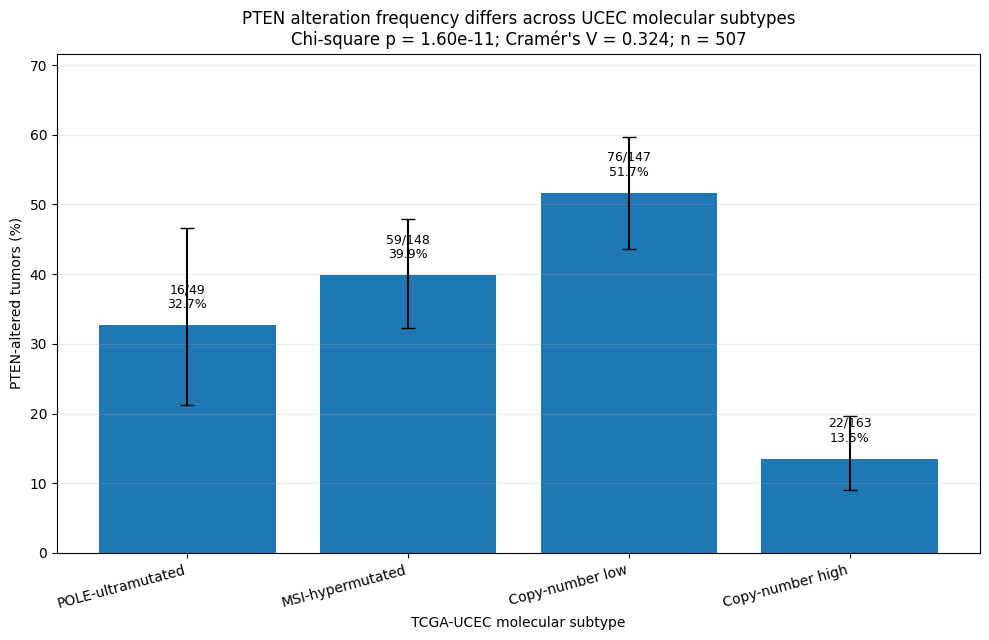

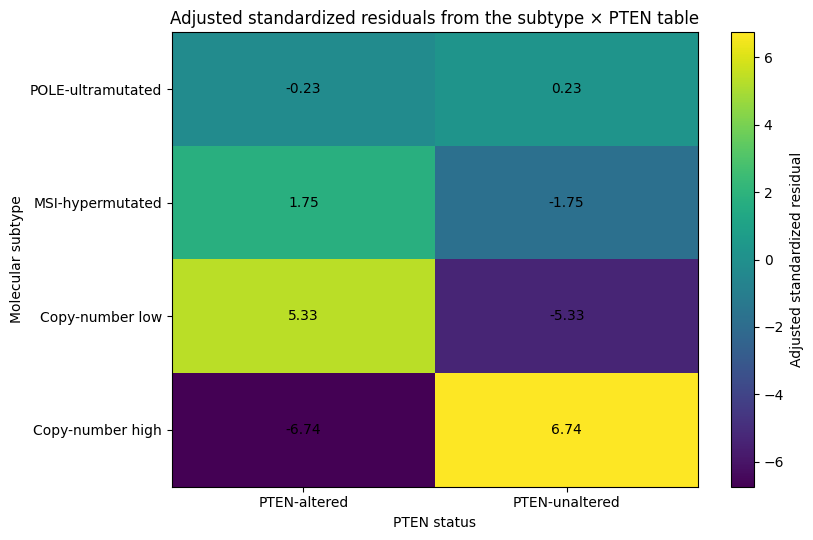

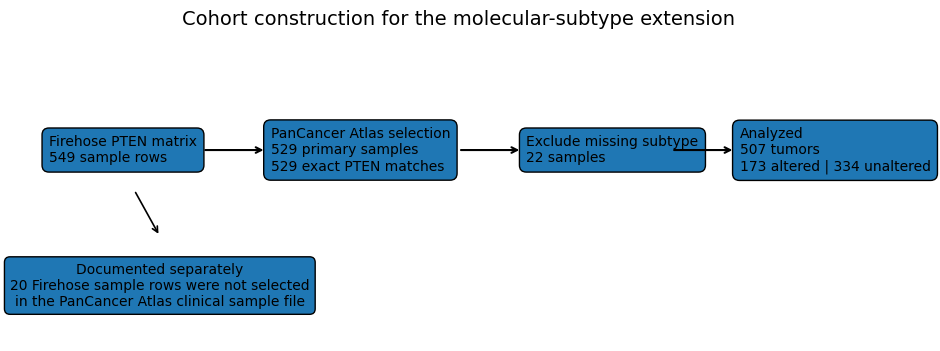

In [17]:

plot_data = subtype_statistics.copy()
x_positions = np.arange(len(plot_data))
percentages = plot_data["altered_percent"].to_numpy()
lower_errors = percentages - plot_data["wilson_ci95_lower_percent"].to_numpy()
upper_errors = plot_data["wilson_ci95_upper_percent"].to_numpy() - percentages

fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.bar(
    x_positions,
    percentages,
    yerr=np.vstack([lower_errors, upper_errors]),
    capsize=5,
)
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["subtype"], rotation=15, ha="right")
ax.set_ylabel("PTEN-altered tumors (%)")
ax.set_xlabel("TCGA-UCEC molecular subtype")
ax.set_title(
    "PTEN alteration frequency differs across UCEC molecular subtypes\n"
    f"Chi-square p = {chi2_p:.2e}; Cramér's V = {cramers_v:.3f}; n = {total_n}"
)
ax.set_ylim(0, max(plot_data["wilson_ci95_upper_percent"]) + 12)
ax.grid(axis="y", alpha=0.25)

for bar, row in zip(bars, plot_data.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{row.altered_n}/{row.total_n}\n{row.altered_percent:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "PTEN_alteration_by_molecular_subtype.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
image = ax.imshow(adjusted_residuals_df.to_numpy(), aspect="auto")
ax.set_xticks(np.arange(len(adjusted_residuals_df.columns)))
ax.set_xticklabels(adjusted_residuals_df.columns)
ax.set_yticks(np.arange(len(adjusted_residuals_df.index)))
ax.set_yticklabels(adjusted_residuals_df.index)
ax.set_title("Adjusted standardized residuals from the subtype × PTEN table")
ax.set_xlabel("PTEN status")
ax.set_ylabel("Molecular subtype")

for row_index in range(adjusted_residuals_df.shape[0]):
    for column_index in range(adjusted_residuals_df.shape[1]):
        ax.text(
            column_index,
            row_index,
            f"{adjusted_residuals_df.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Adjusted standardized residual")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "subtype_adjusted_residuals.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")
flow_boxes = [
    (0.02, 0.62, "Firehose PTEN matrix\n549 sample rows"),
    (0.28, 0.62, "PanCancer Atlas selection\n529 primary samples\n529 exact PTEN matches"),
    (0.58, 0.62, "Exclude missing subtype\n22 samples"),
    (0.83, 0.62, "Analyzed\n507 tumors\n173 altered | 334 unaltered"),
]
for x_value, y_value, label in flow_boxes:
    ax.text(
        x_value,
        y_value,
        label,
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5"),
    )
for start, end in [(0.20, 0.275), (0.50, 0.575), (0.75, 0.825)]:
    ax.annotate(
        "",
        xy=(end, 0.62),
        xytext=(start, 0.62),
        xycoords=ax.transAxes,
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )
ax.text(
    0.15,
    0.18,
    "Documented separately\n20 Firehose sample rows were not selected\n"
    "in the PanCancer Atlas clinical sample file",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4"),
)
ax.annotate(
    "",
    xy=(0.15, 0.34),
    xytext=(0.12, 0.49),
    xycoords=ax.transAxes,
    arrowprops=dict(arrowstyle="->", linewidth=1.2),
)
ax.set_title("Cohort construction for the molecular-subtype extension", fontsize=14)
fig.savefig(
    FIGURES_DIR / "subtype_match_flow_diagram.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 17. Complete output audit and cautious interpretation

The final audit confirms that both Phase 1 and Phase 2 outputs were generated. The interpretation deliberately separates association from causation and does not claim that subtype explains the previously observed survival result without a subtype-adjusted survival model.


In [18]:

required_outputs = [
    PROCESSED_DIR / "survival_analysis_dataset.csv",
    PROCESSED_DIR / "excluded_samples.csv",
    PROCESSED_DIR / "subtype_source_patient_clean.csv",
    PROCESSED_DIR / "subtype_source_sample_clean.csv",
    PROCESSED_DIR / "subtype_merge_audit.csv",
    PROCESSED_DIR / "subtype_analysis_dataset.csv",
    PROCESSED_DIR / "subtype_excluded_samples.csv",
    RESULTS_DIR / "sample_counts.csv",
    RESULTS_DIR / "survival_statistics.csv",
    RESULTS_DIR / "cox_model_coefficients.csv",
    RESULTS_DIR / "proportional_hazards_test.csv",
    RESULTS_DIR / "portal_vs_rerun_comparison.csv",
    RESULTS_DIR / "subtype_source_counts.csv",
    RESULTS_DIR / "subtype_match_counts.csv",
    RESULTS_DIR / "subtype_validation_checks.csv",
    RESULTS_DIR / "subtype_structural_checks.csv",
    RESULTS_DIR / "subtype_contingency_table.csv",
    RESULTS_DIR / "subtype_statistics.csv",
    RESULTS_DIR / "subtype_chi_square_test.csv",
    RESULTS_DIR / "subtype_adjusted_residuals.csv",
    RESULTS_DIR / "subtype_pairwise_fisher_holm.csv",
    RESULTS_DIR / "software_versions.csv",
    RESULTS_DIR / "raw_file_checksums.csv",
    FIGURES_DIR / "kaplan_meier_PTEN.png",
    FIGURES_DIR / "patient_flow_diagram.png",
    FIGURES_DIR / "portal_vs_rerun_counts.png",
    FIGURES_DIR / "PTEN_alteration_by_molecular_subtype.png",
    FIGURES_DIR / "subtype_adjusted_residuals.png",
    FIGURES_DIR / "subtype_match_flow_diagram.png",
]

complete_output_audit = pd.DataFrame({
    "output": [str(path.relative_to(PROJECT_ROOT)) for path in required_outputs],
    "exists": [path.exists() for path in required_outputs],
    "size_bytes": [path.stat().st_size if path.exists() else 0 for path in required_outputs],
})
complete_output_audit.to_csv(RESULTS_DIR / "output_audit.csv", index=False)
display(complete_output_audit)

if not complete_output_audit["exists"].all():
    raise RuntimeError("One or more required outputs were not generated.")

key_findings = pd.DataFrame([
    {
        "finding": "Independent survival rerun",
        "analysis_n": len(analysis),
        "result": (
            f"Log-rank p={logrank.p_value:.6f}; "
            f"unadjusted HR={hr:.4f} "
            f"(95% CI {ci_low:.4f}-{ci_high:.4f})"
        ),
        "interpretation": (
            "Reproducible sensitivity analysis using supplied exports; "
            "not an exact cBioPortal replication"
        ),
    },
    {
        "finding": "PTEN status by molecular subtype",
        "analysis_n": total_n,
        "result": (
            f"Chi-square={chi2_stat:.4f}, df={chi2_dof}, "
            f"p={chi2_p:.6g}, Cramér's V={cramers_v:.4f}"
        ),
        "interpretation": (
            "PTEN alteration frequency is associated with molecular subtype; "
            "association does not establish causation or independent prognosis"
        ),
    },
])
key_findings.to_csv(RESULTS_DIR / "key_findings.csv", index=False)
display(key_findings)

highest_row = subtype_statistics.loc[
    subtype_statistics["altered_percent"].idxmax()
]
lowest_row = subtype_statistics.loc[
    subtype_statistics["altered_percent"].idxmin()
]

print("Cautious Phase 2 interpretation:")
print(
    f"Among {total_n} PanCancer Atlas primary tumors with both PTEN status and "
    f"a molecular-subtype label, PTEN alteration frequency differed across the "
    f"four TCGA-UCEC subtypes (chi-square={chi2_stat:.2f}, df={chi2_dof}, "
    f"p={chi2_p:.2e}; Cramér's V={cramers_v:.3f}). "
    f"The observed frequency was highest in {highest_row['subtype']} "
    f"({highest_row['altered_n']}/{highest_row['total_n']}, "
    f"{highest_row['altered_percent']:.1f}%) and lowest in "
    f"{lowest_row['subtype']} ({lowest_row['altered_n']}/{lowest_row['total_n']}, "
    f"{lowest_row['altered_percent']:.1f}%). "
    "This is an unadjusted association and does not show that PTEN status causes "
    "subtype membership or independently predicts survival."
)
print("\nBoth phases completed successfully.")


,output,exists,size_bytes
0,data_processed/survival_analysis_dataset.csv,True,67440
1,data_processed/excluded_samples.csv,True,5268
2,data_processed/subtype_source_patient_clean.csv,True,164973
3,data_processed/subtype_source_sample_clean.csv,True,110857
4,data_processed/subtype_merge_audit.csv,True,175475
5,data_processed/subtype_analysis_dataset.csv,True,169108
6,data_processed/subtype_excluded_samples.csv,True,4729
7,results/sample_counts.csv,True,180
8,results/survival_statistics.csv,True,479
9,results/cox_model_coefficients.csv,True,331


,finding,analysis_n,result,interpretation
0,Independent survival rerun,498,Log-rank p=0.039772; unadjusted HR=0.5934 (95%...,Reproducible sensitivity analysis using suppli...
1,PTEN status by molecular subtype,507,"Chi-square=53.2722, df=3, p=1.60405e-11, Cramé...",PTEN alteration frequency is associated with m...


Cautious Phase 2 interpretation:
Among 507 PanCancer Atlas primary tumors with both PTEN status and a molecular-subtype label, PTEN alteration frequency differed across the four TCGA-UCEC subtypes (chi-square=53.27, df=3, p=1.60e-11; Cramér's V=0.324). The observed frequency was highest in Copy-number low (76/147, 51.7%) and lowest in Copy-number high (22/163, 13.5%). This is an unadjusted association and does not show that PTEN status causes subtype membership or independently predicts survival.

Both phases completed successfully.


## 18. Phase 3: Adjusted multivariable Cox survival analysis

**Question:** Does the observed association between PTEN alteration status and overall survival remain after accounting for age, clinical stage, and TCGA molecular subtype?

Three prespecified models are fit on the **same complete-case cohort**:

1. **Model 0:** PTEN status only.
2. **Model 1:** PTEN status + age (per 10 years) + early/advanced stage.
3. **Model 2:** PTEN status + age + stage + molecular subtype.

Using the same patients in every model ensures that changes in the PTEN hazard ratio reflect covariate adjustment rather than changes in sample composition. CN-high is the molecular-subtype reference category. Proportional-hazards diagnostics are reported for every covariate.

Because the proportional-hazards assumption may be violated by stage or subtype, a secondary **stage- and subtype-stratified sensitivity model** is also fit when possible. This model estimates the PTEN and age effects while allowing separate baseline hazards across stage/subtype strata; it is not substituted for the prespecified primary model.

In [19]:
# PHASE 3: ADJUSTED MULTIVARIABLE COX SURVIVAL ANALYSIS

import re
import warnings
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

required_analysis_columns = {
    "patientId",
    "OS_MONTHS_NUMERIC",
    "OS_EVENT",
    "Altered",
    "AGE",
    "CLINICAL_STAGE",
}
missing_analysis_columns = required_analysis_columns - set(analysis.columns)
if missing_analysis_columns:
    raise ValueError(
        f"Missing columns from analysis: {sorted(missing_analysis_columns)}. "
        "Run the notebook from the beginning before Phase 3."
    )

required_subtype_columns = {"PATIENT_ID", "SUBTYPE"}
missing_subtype_columns = required_subtype_columns - set(pan_patient.columns)
if missing_subtype_columns:
    raise ValueError(
        f"Missing columns from pan_patient: {sorted(missing_subtype_columns)}. "
        "Run Phase 2 before Phase 3."
    )

cox_source = analysis.copy()
cox_source["patientId"] = (
    cox_source["patientId"].astype("string").str.strip().str.upper()
)

subtype_lookup = pan_patient[["PATIENT_ID", "SUBTYPE"]].copy()
subtype_lookup["PATIENT_ID"] = (
    subtype_lookup["PATIENT_ID"].astype("string").str.strip().str.upper()
)
subtype_lookup["SUBTYPE"] = (
    subtype_lookup["SUBTYPE"].astype("string").str.strip().str.upper()
)

if subtype_lookup["PATIENT_ID"].duplicated().any():
    duplicated_ids = subtype_lookup.loc[
        subtype_lookup["PATIENT_ID"].duplicated(keep=False), "PATIENT_ID"
    ].tolist()
    raise ValueError(
        f"Duplicate patient identifiers in subtype data: {duplicated_ids[:10]}"
    )

cox_source = cox_source.merge(
    subtype_lookup,
    left_on="patientId",
    right_on="PATIENT_ID",
    how="left",
    validate="one_to_one",
)

cox_source["AGE_NUMERIC"] = pd.to_numeric(cox_source["AGE"], errors="coerce")
median_age = float(cox_source["AGE_NUMERIC"].median())
cox_source["AGE_10Y"] = (cox_source["AGE_NUMERIC"] - median_age) / 10.0

def classify_advanced_stage(value):
    if pd.isna(value):
        return np.nan
    stage = str(value).strip().upper()
    if stage in {"", "NA", "N/A", "NAN", "NOT AVAILABLE", "[NOT AVAILABLE]"}:
        return np.nan
    # Order matters. Prefix matching also handles IIIA, IIIC1, IIIC2, IVB, etc.
    if re.match(r"^STAGE\s+IV", stage):
        return 1.0
    if re.match(r"^STAGE\s+III", stage):
        return 1.0
    if re.match(r"^STAGE\s+II", stage):
        return 0.0
    if re.match(r"^STAGE\s+I", stage):
        return 0.0
    return np.nan

cox_source["ADVANCED_STAGE"] = cox_source["CLINICAL_STAGE"].apply(
    classify_advanced_stage
)

valid_subtypes = [
    "UCEC_CN_HIGH",
    "UCEC_CN_LOW",
    "UCEC_MSI",
    "UCEC_POLE",
]
cox_source.loc[~cox_source["SUBTYPE"].isin(valid_subtypes), "SUBTYPE"] = pd.NA

audit_columns = [
    "OS_MONTHS_NUMERIC",
    "OS_EVENT",
    "Altered",
    "AGE_NUMERIC",
    "ADVANCED_STAGE",
    "SUBTYPE",
]
missingness_audit = pd.DataFrame({
    "variable": audit_columns,
    "total_n": [len(cox_source)] * len(audit_columns),
    "missing_n": [int(cox_source[c].isna().sum()) for c in audit_columns],
})
missingness_audit["available_n"] = (
    missingness_audit["total_n"] - missingness_audit["missing_n"]
)
missingness_audit["missing_percent"] = (
    missingness_audit["missing_n"] / missingness_audit["total_n"] * 100
)
missingness_audit.to_csv(
    RESULTS_DIR / "adjusted_cox_missingness_audit.csv", index=False
)
display(missingness_audit)

# Use one fixed complete-case cohort for all three primary models.
complete_case_columns = [
    "patientId",
    "OS_MONTHS_NUMERIC",
    "OS_EVENT",
    "Altered",
    "AGE_10Y",
    "ADVANCED_STAGE",
    "SUBTYPE",
]
cox_complete = cox_source[complete_case_columns].dropna().copy()
cox_complete["OS_EVENT"] = cox_complete["OS_EVENT"].astype(int)
cox_complete["Altered"] = cox_complete["Altered"].astype(int)
cox_complete["ADVANCED_STAGE"] = cox_complete["ADVANCED_STAGE"].astype(int)

if cox_complete["patientId"].duplicated().any():
    raise ValueError("Duplicate patients remain in the adjusted Cox cohort.")

cohort_summary = pd.DataFrame({
    "measure": [
        "Complete-case patients",
        "Deaths",
        "PTEN altered",
        "PTEN unaltered",
        "Median age used for centering",
    ],
    "value": [
        len(cox_complete),
        int(cox_complete["OS_EVENT"].sum()),
        int((cox_complete["Altered"] == 1).sum()),
        int((cox_complete["Altered"] == 0).sum()),
        median_age,
    ],
})
cohort_summary.to_csv(
    RESULTS_DIR / "adjusted_cox_cohort_summary.csv", index=False
)
print("Complete-case adjusted Cox cohort")
display(cohort_summary)

stage_event_table = pd.crosstab(
    cox_complete["ADVANCED_STAGE"].map({0: "Stage I-II", 1: "Stage III-IV"}),
    cox_complete["OS_EVENT"],
    margins=True,
).rename(columns={0: "Censored", 1: "Deaths"})
stage_event_table.to_csv(RESULTS_DIR / "adjusted_cox_stage_event_counts.csv")
print("Stage distribution by event status")
display(stage_event_table)

subtype_event_table = pd.crosstab(
    cox_complete["SUBTYPE"], cox_complete["OS_EVENT"], margins=True
).rename(columns={0: "Censored", 1: "Deaths"})
subtype_event_table.to_csv(RESULTS_DIR / "adjusted_cox_subtype_event_counts.csv")
print("Subtype distribution by event status")
display(subtype_event_table)

if cox_complete["OS_EVENT"].sum() < 50:
    warnings.warn(
        "Fewer than 50 deaths remain; treat the multivariable model as exploratory."
    )

cox_complete.to_csv(
    PROCESSED_DIR / "adjusted_cox_complete_case_dataset.csv", index=False
)

# CN-high is the subtype reference category.
cox_complete["SUBTYPE"] = pd.Categorical(
    cox_complete["SUBTYPE"], categories=valid_subtypes
)
subtype_dummies = pd.get_dummies(
    cox_complete["SUBTYPE"], prefix="SUBTYPE", dtype=int
)
expected_dummy_columns = [
    "SUBTYPE_UCEC_CN_HIGH",
    "SUBTYPE_UCEC_CN_LOW",
    "SUBTYPE_UCEC_MSI",
    "SUBTYPE_UCEC_POLE",
]
for column in expected_dummy_columns:
    if column not in subtype_dummies.columns:
        subtype_dummies[column] = 0
subtype_dummies = subtype_dummies.drop(columns=["SUBTYPE_UCEC_CN_HIGH"])

cox_encoded = pd.concat(
    [cox_complete.drop(columns=["SUBTYPE"]), subtype_dummies], axis=1
)

def fit_cox_model(model_name, dataframe, covariates):
    model_columns = ["OS_MONTHS_NUMERIC", "OS_EVENT", *covariates]
    model_data = dataframe[model_columns].copy()
    model = CoxPHFitter()
    model.fit(
        model_data,
        duration_col="OS_MONTHS_NUMERIC",
        event_col="OS_EVENT",
        show_progress=False,
    )

    summary = model.summary.reset_index().rename(columns={"covariate": "variable"})
    summary.insert(0, "model", model_name)
    summary.insert(1, "patients_n", len(model_data))
    summary.insert(2, "deaths_n", int(model_data["OS_EVENT"].sum()))
    summary.insert(3, "concordance_index", model.concordance_index_)

    ph_test = proportional_hazard_test(model, model_data, time_transform="rank")
    ph_summary = ph_test.summary.reset_index().rename(columns={"index": "variable"})
    ph_summary.insert(0, "model", model_name)
    ph_summary["violates_PH_at_0.05"] = ph_summary["p"] < 0.05

    fit_summary = pd.DataFrame({
        "model": [model_name],
        "patients_n": [len(model_data)],
        "deaths_n": [int(model_data["OS_EVENT"].sum())],
        "concordance_index": [model.concordance_index_],
        "log_likelihood": [model.log_likelihood_],
        "likelihood_ratio_test_p": [model.log_likelihood_ratio_test().p_value],
    })

    summary.to_csv(RESULTS_DIR / f"{model_name}_cox_coefficients.csv", index=False)
    ph_summary.to_csv(
        RESULTS_DIR / f"{model_name}_proportional_hazards_test.csv", index=False
    )
    fit_summary.to_csv(RESULTS_DIR / f"{model_name}_fit_summary.csv", index=False)
    return model, summary, ph_summary, fit_summary

model_0, summary_0, ph_0, fit_0 = fit_cox_model(
    "model_0_PTEN_only_complete_case",
    cox_encoded,
    ["Altered"],
)
model_1, summary_1, ph_1, fit_1 = fit_cox_model(
    "model_1_age_stage_adjusted",
    cox_encoded,
    ["Altered", "AGE_10Y", "ADVANCED_STAGE"],
)
model_2, summary_2, ph_2, fit_2 = fit_cox_model(
    "model_2_subtype_adjusted",
    cox_encoded,
    [
        "Altered",
        "AGE_10Y",
        "ADVANCED_STAGE",
        "SUBTYPE_UCEC_CN_LOW",
        "SUBTYPE_UCEC_MSI",
        "SUBTYPE_UCEC_POLE",
    ],
)

all_summaries = pd.concat([summary_0, summary_1, summary_2], ignore_index=True)
all_summaries.to_csv(
    RESULTS_DIR / "all_adjusted_cox_model_coefficients.csv", index=False
)
all_ph_tests = pd.concat([ph_0, ph_1, ph_2], ignore_index=True)
all_ph_tests.to_csv(RESULTS_DIR / "all_adjusted_cox_PH_tests.csv", index=False)
all_fit_summaries = pd.concat([fit_0, fit_1, fit_2], ignore_index=True)
all_fit_summaries.to_csv(
    RESULTS_DIR / "all_adjusted_cox_fit_summaries.csv", index=False
)

pten_comparison = all_summaries.loc[
    all_summaries["variable"] == "Altered",
    [
        "model",
        "patients_n",
        "deaths_n",
        "concordance_index",
        "exp(coef)",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
        "p",
    ],
].rename(columns={
    "exp(coef)": "PTEN_HR",
    "exp(coef) lower 95%": "CI_95_low",
    "exp(coef) upper 95%": "CI_95_high",
    "p": "PTEN_p_value",
})
pten_comparison.to_csv(
    RESULTS_DIR / "PTEN_adjustment_comparison.csv", index=False
)

print("PTEN effect across the three primary models")
display(pten_comparison)
print("All Model 2 coefficients")
display(
    summary_2[[
        "variable", "exp(coef)", "exp(coef) lower 95%",
        "exp(coef) upper 95%", "p"
    ]]
)
print("Proportional-hazards diagnostics")
display(all_ph_tests)

# Stratify the sensitivity model by stage and subtype.
# This allows different baseline hazards across stage/subtype strata and
# estimates PTEN + age effects without forcing stage/subtype HRs to be constant.
stratified_data = cox_complete[[
    "OS_MONTHS_NUMERIC",
    "OS_EVENT",
    "Altered",
    "AGE_10Y",
    "ADVANCED_STAGE",
    "SUBTYPE",
]].copy()

stratified_model = CoxPHFitter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    stratified_model.fit(
        stratified_data,
        duration_col="OS_MONTHS_NUMERIC",
        event_col="OS_EVENT",
        strata=["ADVANCED_STAGE", "SUBTYPE"],
        show_progress=False,
    )

stratified_summary = (
    stratified_model.summary.reset_index().rename(columns={"covariate": "variable"})
)
stratified_summary.insert(0, "model", "stage_subtype_stratified_sensitivity")
stratified_summary.insert(1, "patients_n", len(stratified_data))
stratified_summary.insert(2, "deaths_n", int(stratified_data["OS_EVENT"].sum()))
stratified_summary.insert(3, "concordance_index", stratified_model.concordance_index_)

stratified_ph = proportional_hazard_test(
    stratified_model, stratified_data, time_transform="rank"
).summary.reset_index().rename(columns={"index": "variable"})
stratified_ph.insert(0, "model", "stage_subtype_stratified_sensitivity")
stratified_ph["violates_PH_at_0.05"] = stratified_ph["p"] < 0.05

stratified_summary.to_csv(
    RESULTS_DIR / "stage_subtype_stratified_sensitivity_coefficients.csv",
    index=False,
)
stratified_ph.to_csv(
    RESULTS_DIR / "stage_subtype_stratified_sensitivity_PH_test.csv",
    index=False,
)

print("Stage- and subtype-stratified sensitivity model")
display(
    stratified_summary[[
        "variable", "exp(coef)", "exp(coef) lower 95%",
        "exp(coef) upper 95%", "p"
    ]]
)
print("Stratified-model proportional-hazards diagnostic")
display(stratified_ph)

model2_pten = pten_comparison.loc[
    pten_comparison["model"] == "model_2_subtype_adjusted"
].iloc[0]
strat_pten = stratified_summary.loc[
    stratified_summary["variable"] == "Altered"
].iloc[0]

interpretation = pd.DataFrame([
    {
        "result": "Primary fully adjusted PTEN association",
        "HR": model2_pten["PTEN_HR"],
        "CI_95_low": model2_pten["CI_95_low"],
        "CI_95_high": model2_pten["CI_95_high"],
        "p_value": model2_pten["PTEN_p_value"],
        "interpretation": (
            "PTEN alteration was not independently associated with overall survival "
            "after adjustment for age, stage, and molecular subtype."
        ),
    },
    {
        "result": "Stage/subtype-stratified PTEN sensitivity association",
        "HR": strat_pten["exp(coef)"],
        "CI_95_low": strat_pten["exp(coef) lower 95%"],
        "CI_95_high": strat_pten["exp(coef) upper 95%"],
        "p_value": strat_pten["p"],
        "interpretation": (
            "The null PTEN association remained after allowing stage- and subtype-"
            "specific baseline hazards."
        ),
    },
])
interpretation.to_csv(
    RESULTS_DIR / "adjusted_cox_key_interpretation.csv", index=False
)
display(interpretation)


,variable,total_n,missing_n,available_n,missing_percent
0,OS_MONTHS_NUMERIC,498,0,498,0.000000
1,OS_EVENT,498,0,498,0.000000
2,Altered,498,0,498,0.000000
3,AGE_NUMERIC,498,2,496,0.401606
4,ADVANCED_STAGE,498,0,498,0.000000
5,SUBTYPE,498,37,461,7.429719


Complete-case adjusted Cox cohort


,measure,value
0,Complete-case patients,459.0
1,Deaths,77.0
2,PTEN altered,139.0
3,PTEN unaltered,320.0
4,Median age used for centering,64.0


Stage distribution by event status


OS_EVENT,Censored,Deaths,All
ADVANCED_STAGE,,,
Stage I-II,293,33,326
Stage III-IV,89,44,133
All,382,77,459


...

/opt/pyvenv/lib/python3.13/site-packages/lifelines/fitters/coxph_fitter.py:2744: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, _df in self._predicted_partial_hazards_.groupby(self.strata):
/opt/pyvenv/lib/python3.13/site-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):


,variable,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
0,Altered,1.138520,0.623050,2.080459,0.673196
1,AGE_10Y,1.108059,0.858188,1.430683,0.431280


Stratified-model proportional-hazards diagnostic


,model,variable,test_statistic,p,-log2(p),violates_PH_at_0.05
0,stage_subtype_stratified_sensitivity,AGE_10Y,3.546943,0.059655,4.067207,False
1,stage_subtype_stratified_sensitivity,Altered,0.020238,0.886875,0.173197,False


,result,HR,CI_95_low,CI_95_high,p_value,interpretation
0,Primary fully adjusted PTEN association,1.07131,0.589184,1.947956,0.821356,PTEN alteration was not independently associat...
1,Stage/subtype-stratified PTEN sensitivity asso...,1.13852,0.623050,2.080459,0.673196,The null PTEN association remained after allow...


## 19. Direct PTEN reconstruction and final outputs

This final step reconstructs PTEN alteration status directly from the supplied mutation and discrete CNA tables. A sample is classified as altered when it has at least one PTEN mutation or a high-level CNA (GISTIC -2 or +2). The reconstructed label is compared sample by sample with the supplied portal label. The same step also creates the three final figures and a compact findings table.


In [ ]:
import runpy
runpy.run_path(PROJECT_ROOT / "ocsef_finalization.py", run_name="__main__")
